In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from pmdarima.arima import ndiffs
from sklearn.metrics import mean_absolute_error
from utils import meanMAE


In [11]:
np.random.seed(0)

n = 400
t = np.arange(n)

signal = np.sin(2*np.pi*t/50)+0.3*np.random.randn(n)
data = pd.Series(signal)

split = 200
kpss_diffs = ndiffs(data.iloc[:split], alpha=0.05, test='kpss', max_d=6)
adf_diffs = ndiffs(data.iloc[:split], alpha=0.05, test='adf', max_d=6)
n_diffs = max(adf_diffs, kpss_diffs)


/home/mea/nf/venv/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/mea/nf/venv/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


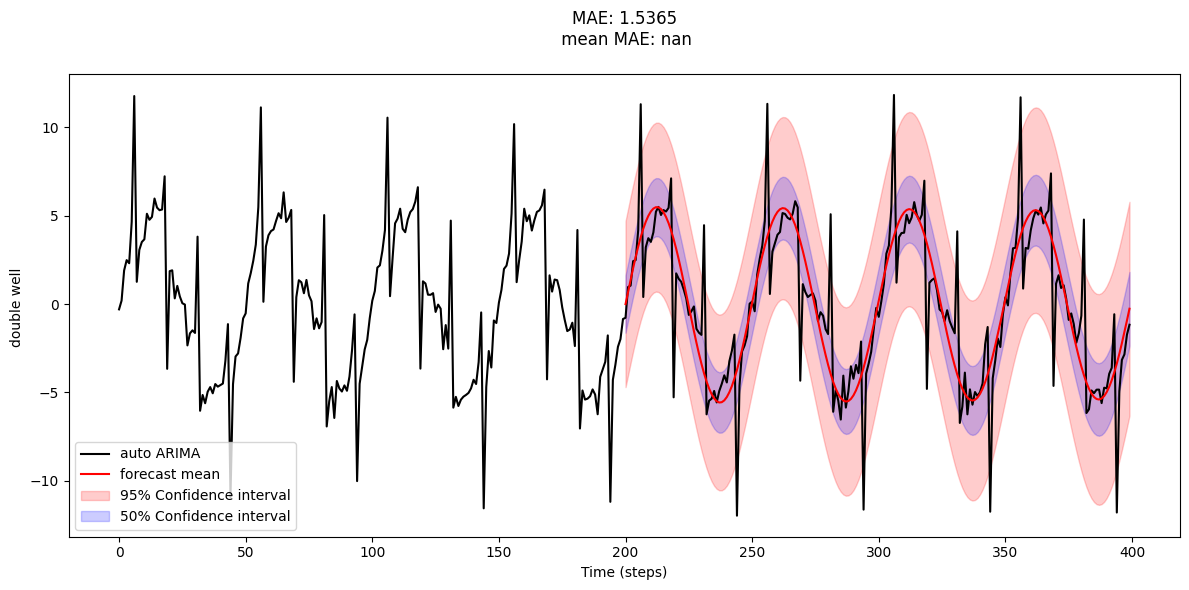

In [ ]:


signal = 5*np.sin(2*np.pi*t/50)+0.5*np.tan(2*np.pi*t/25)+0.5*np.random.randn(n)
data = pd.Series(signal)
train_data = data.iloc[:split]

model = auto_arima(data.iloc[:split],
    seasonal=True,
    suppress_warnings=True)

result = model.arima_res_

steps = len(data) - split
test = data.iloc[split:]

forecast_res = result.get_forecast(steps=steps)
ci = forecast_res.conf_int(alpha=0.05)
ci.index = test.index

n_sim = 0
sims = []
for _ in range(n_sim):
    sim = result.simulate(nsimulations=steps)
    sim.index = test.index
    sims.append(sim)

plt.figure(figsize=(12, 6))

#num_trajs=4
#for _ in range(num_trajs):
#    plt.plot(data.index, x[np.random.randint(0,num_of_simulations)].detach().cpu().numpy(), color="black", label="auto ARIMA")    

plt.plot(data.index, data, color="black", label="auto ARIMA")
plt.plot(test.index,forecast_res.predicted_mean,color="red",label="forecast mean")

for sim in sims:
    plt.plot(sim.index,sim,color="orange",alpha=0.5,label="Simulations" if n_sim == 1 else None)

plt.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1],color="red",alpha=0.2,label="95% Confidence interval")

ci50 = forecast_res.conf_int(alpha=0.5)
ci50.index = test.index
plt.fill_between(ci50.index, ci50.iloc[:, 0], ci50.iloc[:, 1],color="blue",alpha=0.2,label="50% Confidence interval")

plt.title(f'MAE: {mean_absolute_error(data.iloc[split:], forecast_res.predicted_mean):.4f}')
          #\n mean MAE: {meanMAE(data.iloc[split:], sims):.4f}\n')
# {mean_absolute_error(data.iloc[split:], sims[0]):.4f}')
plt.xlabel("Time (steps)")
plt.ylabel("double well ")
plt.legend()
plt.tight_layout()
plt.show()
